In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# READ DATASET

In [2]:
df = pd.read_csv('C:\\Users\\amans\\Downloads\\PS_20174392719_1491204439457_log.csv.zip')

In [3]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.tail(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [6]:
df.shape

(6362620, 11)

In [7]:
df['type'].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

In [8]:
df['isFlaggedFraud'].value_counts()

0    6362604
1         16
Name: isFlaggedFraud, dtype: int64

In [9]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [10]:
df[(df['type']=='TRANSFER') | (df['type']=='PAYEMENT')]['isFraud'].value_counts()

0    528812
1      4097
Name: isFraud, dtype: int64

In [11]:
df = df.drop('isFlaggedFraud' , axis = 1)

In [12]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

# DUPLICATE ROW

In [13]:
df_new = pd.DataFrame(df)
df_new.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Length: 6362620, dtype: bool

In [14]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [15]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


# FEATURE ENGINEERING

In [16]:
df['hour'] = df['step'] % 24  # Extract hour from step (since 1 step = 1 hour)
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)

In [17]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1


In [18]:
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg']+1)

In [19]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.057834
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.087731
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,0.994505
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,1,0.994505
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.280788


In [20]:
df['sender_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change'] = df['oldbalanceDest'] - df['newbalanceDest']

In [21]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.057834,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.087731,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,0.994505,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,1,0.994505,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.280788,11668.14,0.0


In [22]:
df[df['isFraud']==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,1,1,0.994505,181.00,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,1,1,0.994505,181.00,21182.00
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,1,1,0.999644,2806.00,0.00
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,1,1,0.999644,2806.00,26202.00
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,1,1,0.999950,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,23,0,0.999997,339682.13,-339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,23,0,1.000000,6311409.28,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,23,0,1.000000,6311409.28,-6311409.27
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,23,0,0.999999,850002.52,0.00


In [23]:
df['orig_balance_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['dest_balance_zero'] = (df['oldbalanceDest'] == 0).astype(int)

In [24]:
df.sample(4)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero
5778274,400,TRANSFER,271698.37,C582579521,0.00,0.00,C1446374678,3.352682e+05,6.069666e+05,0,16,0,271698.370000,0.00,-271698.37,1,0
4966634,351,CASH_OUT,27391.05,C1328519284,14742.00,0.00,C1640920899,1.314678e+08,1.314952e+08,0,15,0,1.857902,14742.00,-27391.05,0,0
4139222,303,CASH_IN,169518.41,C828270634,5024.00,174542.41,C1184514271,0.000000e+00,0.000000e+00,0,15,0,33.735007,-169518.41,0.00,0,1
5847431,402,PAYMENT,41707.50,C512471947,217304.14,175596.64,M1260387570,0.000000e+00,0.000000e+00,0,18,0,0.191931,41707.50,0.00,0,1


In [25]:
df[df['isFraud'] == 1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,1,1,0.994505,181.00,0.00,0,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,1,1,0.994505,181.00,21182.00,0,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,1,1,0.999644,2806.00,0.00,0,1
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,1,1,0.999644,2806.00,26202.00,0,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,1,1,0.999950,20128.00,0.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,23,0,0.999997,339682.13,-339682.13,0,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,23,0,1.000000,6311409.28,0.00,0,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,23,0,1.000000,6311409.28,-6311409.27,0,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,23,0,0.999999,850002.52,0.00,0,1


In [26]:
dummies = pd.get_dummies(df['type']).astype(int)
dummies.tail(4)

,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
6362616,0,0,0,0,1
6362617,0,1,0,0,0
6362618,0,0,0,0,1
6362619,0,1,0,0,0


In [27]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [28]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.057834,9839.64,0.0,0,1,0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.087731,1864.28,0.0,0,1,0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,0.994505,181.00,0.0,0,1,0,0,0,1
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,1,0.994505,181.00,21182.0,0,0,1,0,0,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.280788,11668.14,0.0,0,1,0,0,1,0


In [29]:
df['type_TRANSFER'] = df['type_TRANSFER'].astype(int)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.057834,9839.64,0.0,0,1,0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.087731,1864.28,0.0,0,1,0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,1,0.994505,181.00,0.0,0,1,0,0,0,1
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,1,0.994505,181.00,21182.0,0,0,1,0,0,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.280788,11668.14,0.0,0,1,0,0,1,0


In [30]:
df.drop(['nameOrig' , 'nameDest'] , axis = 1 , inplace = True)

In [31]:
df.shape

(6362620, 18)

In [32]:
df.sample(10)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3066896,235,294864.83,30532.00,325396.83,0.00,0.00,0,19,0,9.657251,-294864.83,0.00,0,1,0,0,0,0
5469111,379,386684.91,148931.00,0.00,65033.49,451718.40,0,19,0,2.596386,148931.00,-386684.91,0,0,0,0,0,1
459949,19,46167.02,49905.00,3737.98,0.00,18382.56,0,19,0,0.925080,46167.02,-18382.56,0,1,1,0,0,0
2420515,202,227734.95,5945889.18,6173624.13,951561.64,723826.69,0,10,0,0.038301,-227734.95,227734.95,0,0,0,0,0,0
2992033,232,201533.04,2175.00,203708.04,0.00,0.00,0,16,0,92.616287,-201533.04,0.00,0,1,0,0,0,0
3531440,259,244169.49,0.00,0.00,2334390.49,2578559.98,0,19,0,244169.490000,0.00,-244169.49,1,0,1,0,0,0
1652586,158,11545.84,203285.00,191739.16,0.00,0.00,0,14,0,0.056796,11545.84,0.00,0,1,0,0,1,0
3884956,283,2429.99,0.00,0.00,0.00,0.00,0,19,0,2429.990000,0.00,0.00,1,1,0,0,1,0
1102030,130,16227.83,0.00,0.00,0.00,0.00,0,10,0,16227.830000,0.00,0.00,1,1,0,0,1,0
1143302,131,102132.57,0.00,0.00,315300.74,417433.31,0,11,0,102132.570000,0.00,-102132.57,1,0,1,0,0,0


<Axes: >

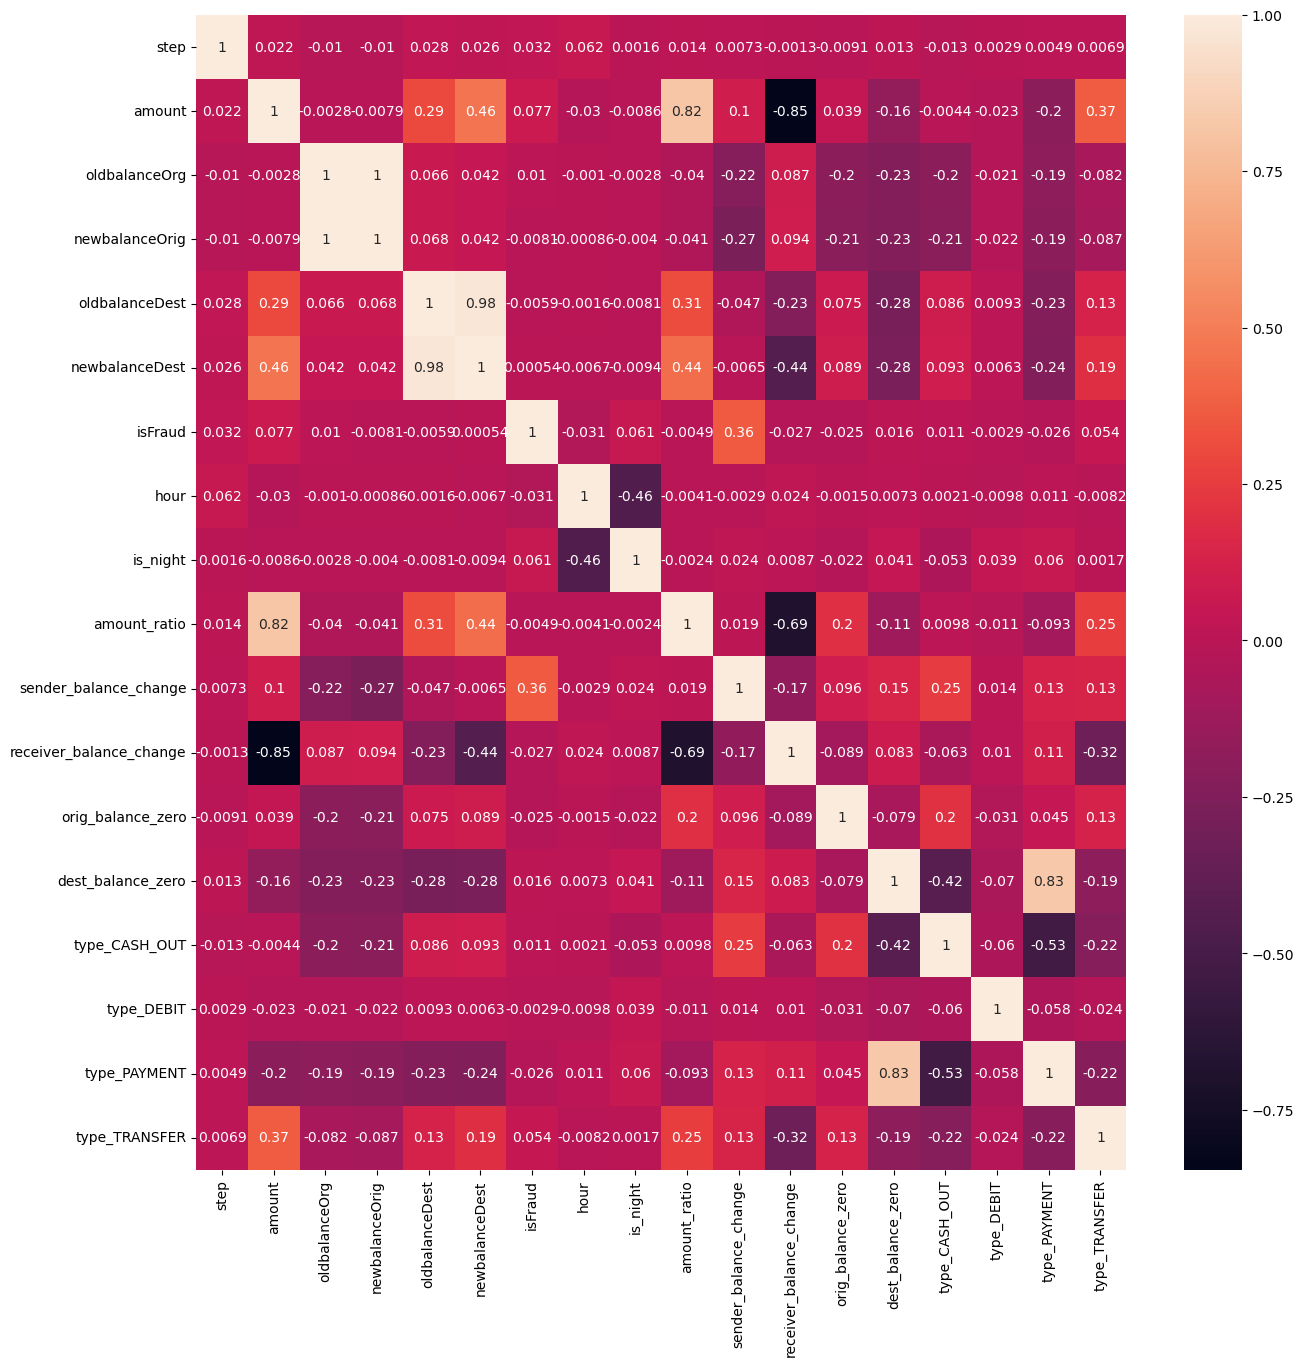

In [33]:
corr = df.corr()
plt.figure(figsize = (15 , 15))
sns.heatmap(corr,annot = True)

In [34]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,1.532145e+01,1.769790e-02,7.067448e+04,-2.123056e+04,-1.242947e+05,3.304376e-01,4.250431e-01,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,4.321799e+00,1.318510e-01,5.084243e+05,1.466433e+05,8.129391e+05,4.703707e-01,4.943496e-01,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.915268e+06,-1.056878e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,0.000000e+00,2.344011e-01,0.000000e+00,-1.491054e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,1.600000e+01,0.000000e+00,6.453832e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,1.900000e+01,0.000000e+00,1.228776e+04,1.015044e+04,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,2.300000e+01,1.000000e+00,9.244552e+07,1.000000e+07,1.306083e+07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


# INDEPENDENT & DEPENDENT FEATURES

In [35]:
x = df.drop('isFraud' , axis = 1)
y = df['isFraud']

In [36]:
x

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,1,1,0.057834,9839.64,0.00,0,1,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,1,1,0.087731,1864.28,0.00,0,1,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,1,1,0.994505,181.00,0.00,0,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,1,1,0.994505,181.00,21182.00,0,0,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,1,1,0.280788,11668.14,0.00,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,23,0,0.999997,339682.13,-339682.13,0,1,1,0,0,0
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,23,0,1.000000,6311409.28,0.00,0,1,0,0,0,1
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,23,0,1.000000,6311409.28,-6311409.27,0,0,1,0,0,0
6362618,743,850002.52,850002.52,0.00,0.00,0.00,23,0,0.999999,850002.52,0.00,0,1,0,0,0,1


In [37]:
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

# TRAIN-TEST-SPLIT

In [38]:
x_train , x_test, y_train,y_test = train_test_split(x,y,random_state = 42 ,test_size = 0.25 , shuffle = True)

In [39]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((4771965, 17), (1590655, 17), (4771965,), (1590655,))

# MODEL TRAINING

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [41]:
x_train_scaled

array([[ 0.55236372, -0.05962331,  0.4411466 , ..., -0.08098062,
        -0.71462353, -0.30233948],
       [-1.59064262, -0.28317422, -0.17255805, ..., -0.08098062,
         1.39933819, -0.30233948],
       [-0.39618007, -0.28862753, -0.28849056, ..., -0.08098062,
         1.39933819, -0.30233948],
       ...,
       [ 0.74909873, -0.28049731, -0.2682272 , ..., -0.08098062,
        -0.71462353, -0.30233948],
       [ 0.44696997, -0.17702838, -0.28173265, ..., -0.08098062,
        -0.71462353, -0.30233948],
       [-0.59291508, -0.14939193, -0.22084488, ..., -0.08098062,
        -0.71462353, -0.30233948]])

In [42]:
x_test_scaled

array([[ 0.24320871,  0.2491613 , -0.28153278, ..., -0.08098062,
        -0.71462353, -0.30233948],
       [-1.60469513, -0.27872771, -0.27824077, ..., -0.08098062,
         1.39933819, -0.30233948],
       [-1.63982638, -0.04571793, -0.25183986, ..., -0.08098062,
        -0.71462353, -0.30233948],
       ...,
       [ 0.72801998, -0.10066533, -0.28154144, ..., -0.08098062,
        -0.71462353, -0.30233948],
       [ 0.1026837 ,  0.17228629,  1.83102963, ..., -0.08098062,
        -0.71462353, -0.30233948],
       [-0.42428507, -0.27131073, -0.2887604 , ..., -0.08098062,
         1.39933819, -0.30233948]])

# LOGESTIC REGRESSION

In [43]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 1000)

In [44]:
lr.fit(x_train_scaled , y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred1 = lr.predict(x_test_scaled)
y_pred1

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [46]:
print(f"y_test_shape:{len(y_test)}")
print(f"y_pred1_shape:{len(y_pred1)}")

y_test_shape:1590655
y_pred1_shape:1590655


In [47]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
acc_score = accuracy_score(y_test , y_pred1)
print(f"accuracy score:{acc_score}")
print()
print(f"confusion matrix:")
print(confusion_matrix(y_test , y_pred1))
print(f"classification report :")
print(classification_report(y_test , y_pred1))

accuracy score:0.9993700708198824

confusion matrix:
[[1588504     106]
 [    896    1149]]
classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588610
           1       0.92      0.56      0.70      2045

    accuracy                           1.00   1590655
   macro avg       0.96      0.78      0.85   1590655
weighted avg       1.00      1.00      1.00   1590655



# DECISION TREE CLASSIFIER

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
dt = DecisionTreeClassifier(max_depth = 5 , class_weight = {0:1 ,1:10})

In [50]:
dt.fit(x_train ,y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 10}, max_depth=5)

# VISUALIZE THE DECISION TREE

[Text(0.646551724137931, 0.9166666666666666, 'x[9] <= 440960.516\ngini = 0.025\nsamples = 4771965\nvalue = [4765797, 61680]'),
 Text(0.3620689655172414, 0.75, 'x[9] <= 141410.492\ngini = 0.013\nsamples = 4763627\nvalue = [4760521, 31060]'),
 Text(0.1724137931034483, 0.5833333333333334, 'x[0] <= 718.5\ngini = 0.007\nsamples = 4665604\nvalue = [4663954, 16500]'),
 Text(0.13793103448275862, 0.4166666666666667, 'x[9] <= 54235.35\ngini = 0.007\nsamples = 4665541\nvalue = [4663954, 15870]'),
 Text(0.06896551724137931, 0.25, 'x[1] <= 0.01\ngini = 0.004\nsamples = 4456325\nvalue = [4455528, 7970]'),
 Text(0.034482758620689655, 0.08333333333333333, 'gini = 0.0\nsamples = 12\nvalue = [0, 120]'),
 Text(0.10344827586206896, 0.08333333333333333, 'gini = 0.004\nsamples = 4456313\nvalue = [4455528, 7850]'),
 Text(0.20689655172413793, 0.25, 'x[6] <= 8.5\ngini = 0.07\nsamples = 209216\nvalue = [208426, 7900]'),
 Text(0.1724137931034483, 0.08333333333333333, 'gini = 0.497\nsamples = 2669\nvalue = [2393,

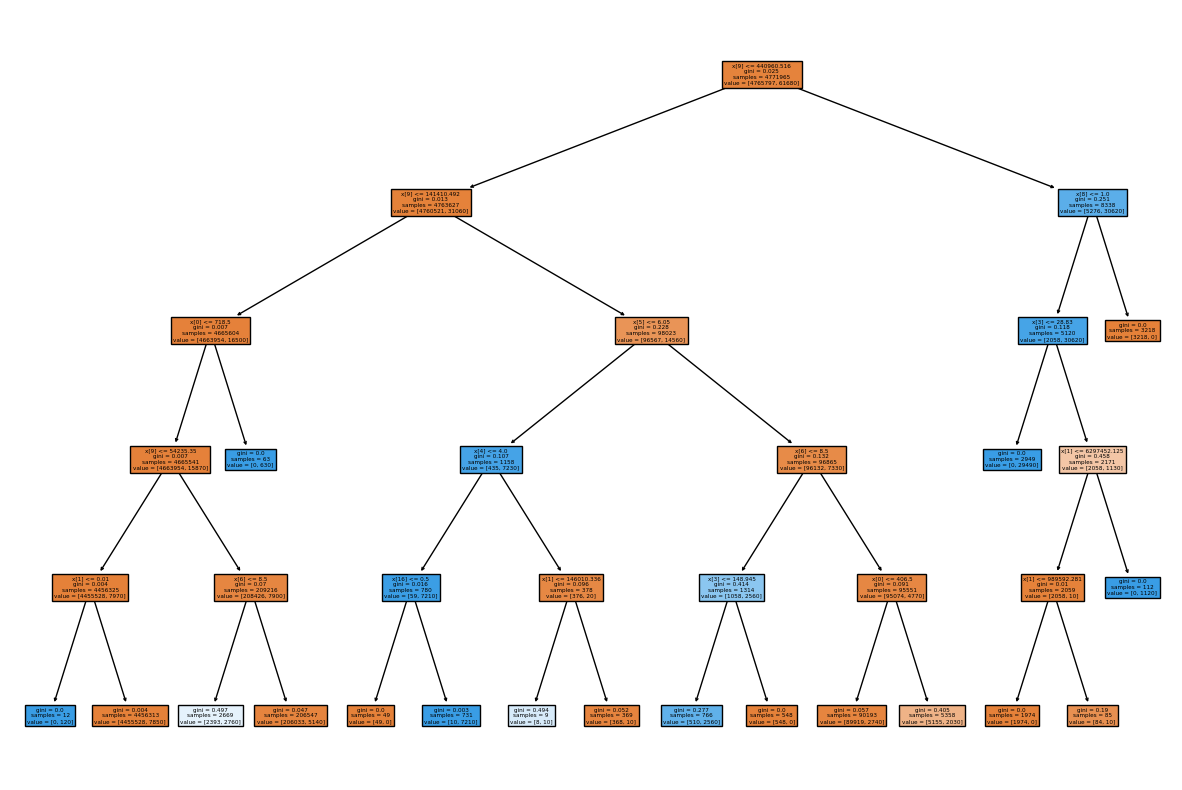

In [51]:
from sklearn import tree
plt.figure(figsize = (15, 10))
tree.plot_tree(dt , filled = True)

In [52]:
dt.get_depth()

5

In [53]:
y_pred = dt.predict(x_test)

In [54]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

# ACCURACY 

In [55]:
acc_score = accuracy_score(y_test , y_pred)
print(f"accuracy score:{acc_score}")
print()
print(f"confusion matrix:")
print(confusion_matrix(y_test , y_pred))
print(f"classification report :")
print(classification_report(y_test , y_pred))

accuracy score:0.9990117278731089

confusion matrix:
[[1587625     985]
 [    587    1458]]
classification report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588610
           1       0.60      0.71      0.65      2045

    accuracy                           1.00   1590655
   macro avg       0.80      0.86      0.82   1590655
weighted avg       1.00      1.00      1.00   1590655



# RANDOM FOREST CLASSIFIER

In [56]:
from sklearn.ensemble import RandomForestClassifier
ref_forest = RandomForestClassifier(n_estimators = 100 ,  class_weight = {0:1 ,1:10} , random_state = 42)

In [ ]:
ref_forest.fit(x_train , y_train)

In [ ]:
y_pred = ref_forest.predict(x_test)
y_pred

In [ ]:
acc_score = accuracy_score(y_test , y_pred)*100
print(f"accuracy score:{acc_score}")
print()
print(f"confusion matrix:")
print(confusion_matrix(y_test , y_pred))
print(f"classification report :")
print(classification_report(y_test , y_pred))